# Import external Libraries

In [118]:
!pip install ydata_profiling
!pip install --upgrade xgboost

DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
from ydata_profiling import ProfileReport

# Import Drive

In [120]:
# from google.colab import drive
# drive.mount('/content/drive')

# Import Libraries

In [121]:

import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from keras.models import Sequential
from IPython.display import display, Markdown
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, classification_report, accuracy_score
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, BatchNormalization, Activation


# Import Data

In [122]:
X_path = r'C:\Users\themmanouilidis\Thanasis_VsCodes\demo_ONLY_TEST\Jupyter\ext\data\poverty_train_hh_features.csv'
y_path = r'C:\Users\themmanouilidis\Thanasis_VsCodes\demo_ONLY_TEST\Jupyter\ext\data\poverty_train_hh_gt.csv'
test_path = r'C:\Users\themmanouilidis\Thanasis_VsCodes\demo_ONLY_TEST\Jupyter\ext\data\poverty_test_hh_features.csv'

X = pd.read_csv(X_path)
y = pd.read_csv(y_path)
test = pd.read_csv(test_path)

In [123]:
X

,hhid,com,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,...,consumed4200,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000,survey_id
0,100001,1,75,4,594.80627,Female,1,0,0,0,...,Yes,No,No,No,Yes,Yes,Yes,Yes,No,100000
1,100002,1,150,4,1676.27230,Female,2,0,0,0,...,Yes,No,No,No,No,Yes,Yes,No,No,100000
2,100003,1,375,4,506.93719,Male,5,0,0,2,...,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,100000
3,100004,1,375,4,824.61786,Male,5,0,0,1,...,No,Yes,No,No,No,Yes,Yes,No,No,100000
4,100005,1,525,4,351.47644,Male,7,1,0,0,...,Yes,No,No,Yes,No,Yes,Yes,Yes,No,100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104229,337458,1,616,7,143.58849,Female,4,2,1,0,...,Yes,No,No,No,No,Yes,Yes,No,Yes,300000
104230,337459,1,616,7,268.44803,Female,4,0,0,1,...,Yes,No,No,No,No,Yes,No,No,No,300000
104231,337460,1,1540,7,243.47612,Male,10,2,3,2,...,Yes,No,No,Yes,No,Yes,Yes,No,No,300000
104232,337461,1,1232,7,337.12079,Male,8,0,0,3,...,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,300000


In [124]:
y

,survey_id,hhid,cons_ppp17
0,100000,100001,25.258402
1,100000,100002,16.996706
2,100000,100003,13.671848
3,100000,100004,7.189475
4,100000,100005,12.308855
...,...,...,...
104229,300000,337458,2.830888
104230,300000,337459,3.144309
104231,300000,337460,3.319158
104232,300000,337461,6.088739


In [125]:
test

,hhid,com,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,...,consumed4200,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000,survey_id
0,400001,1,320,4,567.80914,Female,4,0,1,0,...,No,No,No,No,No,Yes,Yes,Yes,No,400000
1,400002,1,480,4,561.70367,Female,6,0,1,1,...,Yes,No,No,No,No,Yes,Yes,Yes,No,400000
2,400003,1,320,4,183.16423,Male,4,0,0,0,...,Yes,No,Yes,No,Yes,Yes,No,Yes,No,400000
3,400004,1,320,4,696.02411,Male,4,0,0,1,...,Yes,Yes,No,No,No,Yes,Yes,No,No,400000
4,400005,1,320,4,286.95731,Male,4,0,0,1,...,Yes,No,No,No,No,No,Yes,No,No,400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103018,634209,1,963,8,402.71024,Male,3,0,0,0,...,Yes,No,No,Yes,No,No,Yes,Yes,No,600000
103019,634210,1,2247,8,238.44685,Male,7,1,2,2,...,Yes,Yes,No,Yes,No,Yes,Yes,Yes,No,600000
103020,634211,1,963,8,211.95276,Male,3,0,0,1,...,Yes,No,No,Yes,No,No,Yes,Yes,No,600000
103021,634212,1,642,8,254.34331,Female,2,0,0,0,...,Yes,Yes,No,Yes,No,Yes,No,Yes,No,600000


In [126]:
# Concat X and y with common column hhid
df = pd.merge(X, y, on='hhid', how='inner')
df.drop('survey_id_y', inplace=True, axis=1)
df.rename(columns={'survey_id_x': 'survey_id'}, inplace=True)


# Variable Categorization – Household Welfare Dataset

---

## 1. Identification & Survey Design Variables
*(Not used as predictors, required for survey design and weighting)*

| Variable | Description |
|--------|------------|
| sample | Data sample type |
| hhid | Household unique identifier |
| com | Household member identifier |
| weight | Household sampling weight |
| strata | Stratification variable |

---

## 2. Target Variable (Outcome)

| Variable | Description |
|--------|------------|
| cons_ppp17 | Per-capita daily household expenditure (PPP 2017) |

---

## 3. Utility Expenditures

| Variable | Description |
|--------|------------|
| utl_exp_ppp17 | Household expenditure on utilities (PPP 2017) |

---

## 4. Household Demographics

| Variable | Description |
|--------|------------|
| male | Household head is male |
| age | Age of household head |
| hsize | Household size |
| num_children5 | Number of children under 5 |
| num_children10 | Number of children aged 5–10 |
| num_children18 | Number of children aged 10–18 |
| num_adult_female | Number of female adults (18–69) |
| num_adult_male | Number of male adults (18–69) |
| num_elderly | Number of elderly (70+) |

---

## 5. Housing & Infrastructure Characteristics

| Variable | Description |
|--------|------------|
| owner | Dwelling ownership |
| dweltyp | Type of dwelling |
| water | Access to water supply |
| water_source | Main drinking water source |
| toilet | Presence of toilet facilities |
| sewer | Toilet connected to sewer |
| sanitation_source | Main sanitation system |
| elect | Access to electricity |

---

## 6. Employment & Labor Market

| Variable | Description |
|--------|------------|
| employed | Household head is employed |
| sector1d | Employment sector of household head (ISIC 1-digit) |
| any_nonagric | Any household member in non-agricultural work |
| sworkershh | Share of adults working in the household |
| sfworkershh | Share of adults in formal employment |

---

## 7. Education

| Variable | Description |
|--------|------------|
| educ_max | Highest education level in household |
| share_secondary | Share of adults with secondary education |

---

## 8. Geography & Urbanization

| Variable | Description |
|--------|------------|
| urban | Urban residence indicator |
| region1 | Region 1 |
| region2 | Region 2 |
| region3 | Region 3 |
| region4 | Region 4 |
| region5 | Region 5 |
| region6 | Region 6 |
| region7 | Region 7 |

---

## 9. Food Consumption Indicators (Binary: 1 = Consumed, 0 = Not Consumed)

### 9.1 Cereals & Grains
- consumed100 (Bread)
- consumed200 (Pastries)
- consumed300 (Rice)
- consumed1500 (Corn and corn flour)
- consumed1600 (Wheat and wheat flour)
- consumed1700 (Quinoa)
- consumed1800 (Legume flours)
- consumed1900 (Noodles)

### 9.2 Dairy & Eggs
- consumed400 (Milk)
- consumed700 (Eggs)
- consumed2400 (Fresh cheese)
- consumed2500 (Margarine)
- consumed2600 (Butter)
- consumed2700 (Other dairy products)

### 9.3 Meat, Fish & Animal Products
- consumed800 (Beef and red meat)
- consumed900 (Chicken and poultry)
- consumed1000–1400 (Offal and by-products)
- consumed2000 (Fresh fish)
- consumed2100 (Canned fish)
- consumed2200 (Seafood)

### 9.4 Vegetables & Legumes
- consumed3100 (Lentils, peas, beans)
- consumed3200 (Onions)
- consumed3300 (Tomatoes)
- consumed3400 (Carrots and squash)
- consumed3500 (Corn on the cob)
- consumed3600 (Root crops)
- consumed3700 (Other vegetables)

### 9.5 Fruits
- consumed3800 (Lemon)
- consumed3900 (Citrus and papaya)
- consumed4000 (Bananas)
- consumed4100 (Other fruits)

### 9.6 Fats, Condiments & Spices
- consumed2300 (Oil)
- consumed2800 (Iodized salt)
- consumed2900 (Chili)
- consumed3000 (Spices and seasonings)

### 9.7 Beverages & Prepared Items
- consumed4200 (Coffee, tea, cocoa)
- consumed4300 (Sweets and candies)
- consumed4400 (Alcoholic beverages)
- consumed4500 (Soft drinks)
- consumed4600 (Mineral water and juices)
- consumed4700 (Prepared meals)

### 9.8 Other Food Consumption
- consumed4800 (Other foods)
- consumed4900 (Animal feed)
- consumed5000 (Other food items)

---

## 10. Poverty Lines (Reference Thresholds – Not Predictors)

| Variable | Description |
|--------|------------|
| _pline5 – _pline95 | Poverty lines corresponding to 5th–95th percentiles of welfare distribution |

---

## Modeling Notes
- **Target variable**: `cons_ppp17`
- **Alternative binary target**: `poor = cons_ppp17 < _plineX`
- **Predictors**: Sections 3–9
- **Excluded from modeling**: Sections 1 & 10


# Preprocessing

In [127]:
drop_list = ['com']#, 'hhid'], 'utl_exp_ppp17']
df.drop(drop_list, inplace=True, axis=1)

test.drop(['com'], inplace=True, axis=1)

df

,hhid,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,...,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000,survey_id,cons_ppp17
0,100001,75,4,594.80627,Female,1,0,0,0,75,...,No,No,No,Yes,Yes,Yes,Yes,No,100000,25.258402
1,100002,150,4,1676.27230,Female,2,0,0,0,61,...,No,No,No,No,Yes,Yes,No,No,100000,16.996706
2,100003,375,4,506.93719,Male,5,0,0,2,49,...,Yes,No,Yes,Yes,Yes,Yes,No,Yes,100000,13.671848
3,100004,375,4,824.61786,Male,5,0,0,1,58,...,Yes,No,No,No,Yes,Yes,No,No,100000,7.189475
4,100005,525,4,351.47644,Male,7,1,0,0,57,...,No,No,Yes,No,Yes,Yes,Yes,No,100000,12.308855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104229,337458,616,7,143.58849,Female,4,2,1,0,33,...,No,No,No,No,Yes,Yes,No,Yes,300000,2.830888
104230,337459,616,7,268.44803,Female,4,0,0,1,48,...,No,No,No,No,Yes,No,No,No,300000,3.144309
104231,337460,1540,7,243.47612,Male,10,2,3,2,54,...,No,No,Yes,No,Yes,Yes,No,No,300000,3.319158
104232,337461,1232,7,337.12079,Male,8,0,0,3,49,...,Yes,No,Yes,No,No,Yes,Yes,Yes,300000,6.088739


### EDA analysis
Drop non necessary columns to see clear results

In [128]:
drop_cols = (
    [c for c in df.columns if c.startswith("consumed")] +
    ["survey_id"]
)

df_eda = df.drop(columns=drop_cols)

In [129]:
df_eda

,hhid,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,...,sector1d,region1,region2,region3,region4,region5,region6,region7,urban,cons_ppp17
0,100001,75,4,594.80627,Female,1,0,0,0,75,...,NaN,0,1,0,0,0,0,0,Urban,25.258402
1,100002,150,4,1676.27230,Female,2,0,0,0,61,...,NaN,0,1,0,0,0,0,0,Urban,16.996706
2,100003,375,4,506.93719,Male,5,0,0,2,49,...,"Transport, storage and communications",0,1,0,0,0,0,0,Urban,13.671848
3,100004,375,4,824.61786,Male,5,0,0,1,58,...,Public administration and defence,0,1,0,0,0,0,0,Urban,7.189475
4,100005,525,4,351.47644,Male,7,1,0,0,57,...,Construction,0,1,0,0,0,0,0,Urban,12.308855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104229,337458,616,7,143.58849,Female,4,2,1,0,33,...,Hotels and restaurants,0,0,0,0,1,0,0,Rural,2.830888
104230,337459,616,7,268.44803,Female,4,0,0,1,48,...,NaN,0,0,0,0,1,0,0,Rural,3.144309
104231,337460,1540,7,243.47612,Male,10,2,3,2,54,...,NaN,0,0,0,0,1,0,0,Rural,3.319158
104232,337461,1232,7,337.12079,Male,8,0,0,3,49,...,Wholesale and retail trade,0,0,0,0,1,0,0,Rural,6.088739


In [130]:
# profile = ProfileReport(df_eda, title="YData Profiling Report")
# profile.to_file("df_eda.html")


In [131]:
df.isnull().sum()

hhid              0
weight            0
strata            0
utl_exp_ppp17    85
male              0
                 ..
consumed4800     56
consumed4900     56
consumed5000     66
survey_id         0
cons_ppp17        0
Length: 88, dtype: int64

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104234 entries, 0 to 104233
Data columns (total 88 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   hhid               104234 non-null  int64  
 1   weight             104234 non-null  int64  
 2   strata             104234 non-null  int64  
 3   utl_exp_ppp17      104149 non-null  float64
 4   male               104234 non-null  object 
 5   hsize              104234 non-null  int64  
 6   num_children5      104234 non-null  int64  
 7   num_children10     104234 non-null  int64  
 8   num_children18     104234 non-null  int64  
 9   age                104234 non-null  int64  
 10  owner              104234 non-null  object 
 11  water              104234 non-null  object 
 12  toilet             104234 non-null  object 
 13  sewer              104234 non-null  object 
 14  elect              104234 non-null  object 
 15  water_source       104234 non-null  object 
 16  sa

## Handle non numerical values


In [133]:
# for col in df.columns:
#     unique_vals = np.unique(df[col].astype(str))
#     display(Markdown(f"**Unique values of {col}: {len(unique_vals)}**"))
#     print(unique_vals)

## Plot Nan values

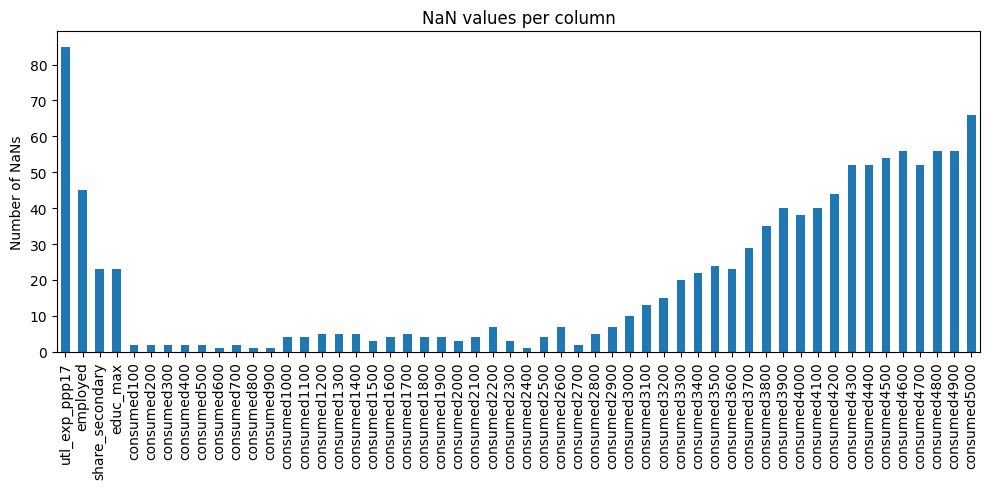

In [134]:
col_with_many_nan_values = ['dweltyp', 'sector1d']
nan_counts = df.drop(col_with_many_nan_values, axis=1).isnull().sum()
nan_counts = nan_counts[nan_counts > 0]

nan_counts.plot(kind='bar', figsize=(10,5))
plt.ylabel('Number of NaNs')
plt.title('NaN values per column')
plt.tight_layout()
plt.show()


In [135]:
print(len(test.dropna()))
print(len(test))
print("-"*10)
print(len(df.dropna()))
print(len(df))

86009
103023
----------
88844
104234


## One hot encoding non numerical values

### For training

In [136]:
columns_to_encode = ['strata', 'dweltyp', 'water_source', 'sanitation_source', 'educ_max', 'sector1d']



for col in columns_to_encode:
  df.loc[df[col].isna(), col] = 'unknown'
  test.loc[test[col].isna(), col] = 'unknown'

  enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
  
  enc.fit(df[[col]])
  
  encoded = enc.transform(df[[col]])
  test_encoded = enc.transform(test[[col]])
  
  enc_df = pd.DataFrame(
      encoded,
      columns=enc.get_feature_names_out([col]),
      index=df.index
  )

  enc_test = pd.DataFrame(
      test_encoded,
      columns=enc.get_feature_names_out([col]),
      index=test.index
  )
  
  test = pd.concat([test, enc_test], axis=1)
  df = pd.concat([df, enc_df], axis=1)
  
  test.drop(col, axis=1, inplace=True)
  df.drop(col, axis=1, inplace=True)

df.dropna(inplace=True)
df

C:\Users\themmanouilidis\AppData\Local\Temp\ipykernel_23776\2187981110.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col].isna(), col] = 'unknown'
C:\Users\themmanouilidis\AppData\Local\Temp\ipykernel_23776\2187981110.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[test[col].isna(), col] = 'unknown'


,hhid,weight,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,...,sector1d_Health and social work,sector1d_Hotels and restaurants,sector1d_Manufacturing,sector1d_Mining and quarrying,"sector1d_Other community, social and personal service activities",sector1d_Public administration and defence,"sector1d_Real estate, renting and business activities","sector1d_Transport, storage and communications",sector1d_Wholesale and retail trade,sector1d_unknown
0,100001,75,594.80627,Female,1,0,0,0,75,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100002,150,1676.27230,Female,2,0,0,0,61,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,100003,375,506.93719,Male,5,0,0,2,49,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,100004,375,824.61786,Male,5,0,0,1,58,Not owner,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,100005,525,351.47644,Male,7,1,0,0,57,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104229,337458,616,143.58849,Female,4,2,1,0,33,Owner,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104230,337459,616,268.44803,Female,4,0,0,1,48,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
104231,337460,1540,243.47612,Male,10,2,3,2,54,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
104232,337461,1232,337.12079,Male,8,0,0,3,49,Owner,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [137]:
test.isna().sum()

hhid                                                       0
weight                                                     0
utl_exp_ppp17                                            283
male                                                       0
hsize                                                      0
                                                        ... 
sector1d_Public administration and defence                 0
sector1d_Real estate, renting and business activities      0
sector1d_Transport, storage and communications             0
sector1d_Wholesale and retail trade                        0
sector1d_unknown                                           0
Length: 134, dtype: int64

In [138]:
nan_rows = test[test.isna().any(axis=1)].copy()
test.dropna(inplace=True)

## Convert data with two values (numerical)

In [139]:
for col in df.columns:
    unique_vals = np.unique(df[col].astype(str))
    if len(unique_vals) == 2:
      display(Markdown(f"**Unique values of {col}:**"))
      print(unique_vals)
      le = LabelEncoder()
      df[col] = le.fit_transform(df[col])  # Apply LabelEncoder to the column of the DataFrame
      print("After label encoding:", np.unique(df[col]))



**Unique values of male:**

['Female' 'Male']
After label encoding: [0 1]


**Unique values of owner:**

['Not owner' 'Owner']
After label encoding: [0 1]


**Unique values of water:**

['Access' 'No access']
After label encoding: [0 1]


**Unique values of toilet:**

['Access' 'No access']
After label encoding: [0 1]


**Unique values of sewer:**

['Access' 'No access']
After label encoding: [0 1]


**Unique values of elect:**

['Access' 'No access']
After label encoding: [0 1]


**Unique values of employed:**

['Employed' 'Not employed']
After label encoding: [0 1]


**Unique values of any_nonagric:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of region1:**

['0' '1']
After label encoding: [0 1]


**Unique values of region2:**

['0' '1']
After label encoding: [0 1]


**Unique values of region3:**

['0' '1']
After label encoding: [0 1]


**Unique values of region4:**

['0' '1']
After label encoding: [0 1]


**Unique values of region5:**

['0' '1']
After label encoding: [0 1]


**Unique values of region6:**

['0' '1']
After label encoding: [0 1]


**Unique values of region7:**

['0' '1']
After label encoding: [0 1]


**Unique values of urban:**

['Rural' 'Urban']
After label encoding: [0 1]


**Unique values of consumed100:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed200:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed300:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed400:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed500:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed600:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed700:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed800:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed900:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1000:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1100:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1200:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1300:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1400:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1500:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1600:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1700:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1800:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed1900:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2000:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2100:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2200:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2300:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2400:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2500:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2600:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2700:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2800:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed2900:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3000:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3100:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3200:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3300:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3400:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3500:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3600:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3700:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3800:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed3900:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4000:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4100:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4200:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4300:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4400:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4500:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4600:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4700:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4800:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed4900:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of consumed5000:**

['No' 'Yes']
After label encoding: [0 1]


**Unique values of strata_1:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_2:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_3:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_4:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_5:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_6:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_7:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of strata_8:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of dweltyp_Detached house:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of dweltyp_Improvised housing unit:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of dweltyp_Other:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of dweltyp_Separate apartment:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of dweltyp_Several buildings connected:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of dweltyp_unknown:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Other:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Piped water into dwelling:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Piped water to yard/plot:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Protected dug well:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Protected spring:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Public tap or standpipe:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Surface water:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of water_source_Tanker-truck:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sanitation_source_A piped sewer system:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sanitation_source_A septic tank:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sanitation_source_No facilities or bush or field:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sanitation_source_Other:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sanitation_source_Pit latrine:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sanitation_source_Pit latrine with slab:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Complete Primary Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Complete Secondary Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Complete Tertiary Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Incomplete Primary Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Incomplete Secondary Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Incomplete Tertiary Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of educ_max_Never attended:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Activities of private households as employers :**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Agriculture, hunting and forestry:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Construction:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Education:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Electricity, gas and water supply:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Financial intermediation:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Fishing:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Health and social work:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Hotels and restaurants:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Manufacturing:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Mining and quarrying:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Other community, social and personal service activities:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Public administration and defence:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Real estate, renting and business activities:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Transport, storage and communications:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_Wholesale and retail trade:**

['0.0' '1.0']
After label encoding: [0 1]


**Unique values of sector1d_unknown:**

['0.0' '1.0']
After label encoding: [0 1]


### For test df

In [140]:
for col in test.columns:
    test_unique_vals = np.unique(test[col].astype(str))
    
    if len(test_unique_vals) == 2:
      display(Markdown(f"**Test: Unique values of {col}:**"))
      print(test_unique_vals)
      le = LabelEncoder()
      test[col] = le.fit_transform(test[col])  # Apply LabelEncoder to the column of the DataFrame
      print("Test: After label encoding:", np.unique(test[col]))


**Test: Unique values of male:**

['Female' 'Male']
Test: After label encoding: [0 1]


**Test: Unique values of owner:**

['Not owner' 'Owner']
Test: After label encoding: [0 1]


**Test: Unique values of water:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of toilet:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of sewer:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of elect:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of employed:**

['Employed' 'Not employed']
Test: After label encoding: [0 1]


**Test: Unique values of any_nonagric:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of region1:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region2:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region3:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region4:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region5:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region6:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region7:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of urban:**

['Rural' 'Urban']
Test: After label encoding: [0 1]


**Test: Unique values of consumed100:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed200:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed300:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed400:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed500:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed600:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed700:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed800:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed900:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1000:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1100:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1200:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1300:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1400:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1500:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1600:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1700:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1800:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed1900:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2000:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2100:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2200:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2300:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2400:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2500:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2600:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2700:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2800:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed2900:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3000:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3100:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3200:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3300:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3400:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3500:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3600:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3700:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3800:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed3900:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4000:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4100:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4200:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4300:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4400:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4500:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4600:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4700:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4800:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed4900:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of consumed5000:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of strata_1:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_2:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_3:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_4:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_5:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_6:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_7:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_8:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Detached house:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Improvised housing unit:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Other:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Separate apartment:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Several buildings connected:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_unknown:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Other:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Piped water into dwelling:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Piped water to yard/plot:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Protected dug well:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Protected spring:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Public tap or standpipe:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Surface water:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Tanker-truck:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_A piped sewer system:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_A septic tank:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_No facilities or bush or field:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_Other:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_Pit latrine:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_Pit latrine with slab:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Complete Primary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Complete Secondary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Complete Tertiary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Incomplete Primary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Incomplete Secondary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Incomplete Tertiary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Never attended:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_unknown:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Activities of private households as employers :**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Agriculture, hunting and forestry:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Construction:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Electricity, gas and water supply:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Financial intermediation:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Fishing:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Health and social work:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Hotels and restaurants:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Manufacturing:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Mining and quarrying:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Other community, social and personal service activities:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Public administration and defence:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Real estate, renting and business activities:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Transport, storage and communications:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Wholesale and retail trade:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_unknown:**

['0.0' '1.0']
Test: After label encoding: [0 1]


## Train a model to fill test set nan values 

### Fill continues nan values with the mean of the test set 

In [141]:
# For share_secondary 
nan_rows['share_secondary'] = nan_rows['share_secondary'].fillna(test['share_secondary'].mean())
nan_rows.isna().sum()

hhid                                                       0
weight                                                     0
utl_exp_ppp17                                            283
male                                                       0
hsize                                                      0
                                                        ... 
sector1d_Public administration and defence                 0
sector1d_Real estate, renting and business activities      0
sector1d_Transport, storage and communications             0
sector1d_Wholesale and retail trade                        0
sector1d_unknown                                           0
Length: 134, dtype: int64

In [142]:
# For utl_exp_ppp17
nan_rows['utl_exp_ppp17'] = nan_rows['utl_exp_ppp17'].fillna(test['utl_exp_ppp17'].mean())
nan_rows.isna().sum()

hhid                                                     0
weight                                                   0
utl_exp_ppp17                                            0
male                                                     0
hsize                                                    0
                                                        ..
sector1d_Public administration and defence               0
sector1d_Real estate, renting and business activities    0
sector1d_Transport, storage and communications           0
sector1d_Wholesale and retail trade                      0
sector1d_unknown                                         0
Length: 134, dtype: int64

In [143]:
for col in nan_rows.columns:
    nan_rows_unique_vals = np.unique(nan_rows[col].astype(str))
    
    if len(nan_rows_unique_vals) == 2:
      display(Markdown(f"**Test: Unique values of {col}:**"))
      print(nan_rows_unique_vals)
      le = LabelEncoder()
      nan_rows[col] = le.fit_transform(nan_rows[col])  # Apply LabelEncoder to the column of the DataFrame
      print("Test: After label encoding:", np.unique(nan_rows[col]))


**Test: Unique values of male:**

['Female' 'Male']
Test: After label encoding: [0 1]


**Test: Unique values of owner:**

['Not owner' 'Owner']
Test: After label encoding: [0 1]


**Test: Unique values of water:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of toilet:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of sewer:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of elect:**

['Access' 'No access']
Test: After label encoding: [0 1]


**Test: Unique values of any_nonagric:**

['No' 'Yes']
Test: After label encoding: [0 1]


**Test: Unique values of region1:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region2:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region3:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region4:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region5:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region6:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of region7:**

['0' '1']
Test: After label encoding: [0 1]


**Test: Unique values of urban:**

['Rural' 'Urban']
Test: After label encoding: [0 1]


**Test: Unique values of strata_1:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_2:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_3:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_4:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_5:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_6:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_7:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of strata_8:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Detached house:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Other:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Separate apartment:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_Several buildings connected:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of dweltyp_unknown:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Other:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Piped water into dwelling:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Piped water to yard/plot:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Protected dug well:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Protected spring:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Public tap or standpipe:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Surface water:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of water_source_Tanker-truck:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_A piped sewer system:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_A septic tank:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_No facilities or bush or field:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_Other:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_Pit latrine:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sanitation_source_Pit latrine with slab:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Complete Primary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Complete Secondary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Complete Tertiary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Incomplete Primary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Incomplete Secondary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Incomplete Tertiary Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_Never attended:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of educ_max_unknown:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Activities of private households as employers :**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Agriculture, hunting and forestry:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Construction:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Education:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Financial intermediation:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Fishing:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Health and social work:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Hotels and restaurants:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Manufacturing:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Mining and quarrying:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Other community, social and personal service activities:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Public administration and defence:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Real estate, renting and business activities:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Transport, storage and communications:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_Wholesale and retail trade:**

['0.0' '1.0']
Test: After label encoding: [0 1]


**Test: Unique values of sector1d_unknown:**

['0.0' '1.0']
Test: After label encoding: [0 1]


In [144]:
nan_rows

,hhid,weight,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,...,sector1d_Health and social work,sector1d_Hotels and restaurants,sector1d_Manufacturing,sector1d_Mining and quarrying,"sector1d_Other community, social and personal service activities",sector1d_Public administration and defence,"sector1d_Real estate, renting and business activities","sector1d_Transport, storage and communications",sector1d_Wholesale and retail trade,sector1d_unknown
63,400064,244,482.332490,0,4,1,1,0,32,0,...,0,0,0,0,0,0,0,0,0,0
405,400406,95,557.163661,1,1,0,0,0,24,1,...,0,0,0,0,0,0,0,0,0,0
566,400567,81,557.163661,1,1,0,0,0,51,1,...,0,0,0,0,0,0,0,0,0,0
1416,401417,133,244.218980,1,1,0,0,1,17,1,...,0,0,0,0,0,0,0,0,1,0
1453,401454,362,557.163661,1,2,0,0,0,76,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102808,633999,666,557.163661,1,9,2,2,3,39,1,...,0,0,0,0,0,0,0,0,0,0
102833,634024,136,557.163661,1,2,0,0,0,63,1,...,0,0,0,0,0,0,0,0,0,0
102835,634026,408,557.163661,1,6,0,2,2,48,1,...,0,0,0,0,0,0,0,0,0,0
102837,634028,272,557.163661,1,4,0,0,2,53,1,...,0,0,0,0,0,0,0,0,0,0


In [145]:
# Convert values to True or False skipping Nan values
nan_rows.loc[:, drop_cols] = (
    nan_rows[drop_cols]
    .replace({'Yes': 1, 'No': 0})
    .fillna(-1)
)

# Same for employees 
nan_rows['employed'] = (
    nan_rows['employed']
    .replace({'Employed': 1, 'Not employed': 0})
    .fillna(-1)
)

nan_rows


C:\Users\themmanouilidis\AppData\Local\Temp\ipykernel_23776\343557477.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Yes': 1, 'No': 0})
C:\Users\themmanouilidis\AppData\Local\Temp\ipykernel_23776\343557477.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Employed': 1, 'Not employed': 0})


,hhid,weight,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,...,sector1d_Health and social work,sector1d_Hotels and restaurants,sector1d_Manufacturing,sector1d_Mining and quarrying,"sector1d_Other community, social and personal service activities",sector1d_Public administration and defence,"sector1d_Real estate, renting and business activities","sector1d_Transport, storage and communications",sector1d_Wholesale and retail trade,sector1d_unknown
63,400064,244,482.332490,0,4,1,1,0,32,0,...,0,0,0,0,0,0,0,0,0,0
405,400406,95,557.163661,1,1,0,0,0,24,1,...,0,0,0,0,0,0,0,0,0,0
566,400567,81,557.163661,1,1,0,0,0,51,1,...,0,0,0,0,0,0,0,0,0,0
1416,401417,133,244.218980,1,1,0,0,1,17,1,...,0,0,0,0,0,0,0,0,1,0
1453,401454,362,557.163661,1,2,0,0,0,76,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102808,633999,666,557.163661,1,9,2,2,3,39,1,...,0,0,0,0,0,0,0,0,0,0
102833,634024,136,557.163661,1,2,0,0,0,63,1,...,0,0,0,0,0,0,0,0,0,0
102835,634026,408,557.163661,1,6,0,2,2,48,1,...,0,0,0,0,0,0,0,0,0,0
102837,634028,272,557.163661,1,4,0,0,2,53,1,...,0,0,0,0,0,0,0,0,0,0


### Convert object type columns to category type to prevent error

In [146]:
nan_rows['employed'] = nan_rows['employed'].astype("int64")
nan_rows[drop_cols] = nan_rows[drop_cols].astype("int64")

In [147]:
# Columns that originally had missing values
nan_cols = nan_rows.columns[(nan_rows == -1).any()].tolist()

for col in nan_cols:

    # mask for rows to predict
    pred_mask = nan_rows[col] == -1

    # training data (only valid labels)
    train_df = nan_rows.loc[~pred_mask]

    x_train = train_df.drop([col, 'hhid'], axis=1)
    y_train = train_df[col]

    # binary only
    if y_train.nunique() == 2:
        print(f'Filling column: {col}')

        model = xgb.XGBClassifier(
            objective='binary:hinge',
            n_estimators=100,
            random_state=0
        )

        model.fit(x_train, y_train)

        # predict only missing (-1)
        X_missing = nan_rows.loc[pred_mask].drop([col, 'hhid'], axis=1)
        preds = model.predict(X_missing)

        # fill predictions
        nan_rows.loc[pred_mask, col] = preds


Filling column: employed
Filling column: consumed100
Filling column: consumed200
Filling column: consumed300
Filling column: consumed400
Filling column: consumed500
Filling column: consumed600
Filling column: consumed700
Filling column: consumed800
Filling column: consumed900
Filling column: consumed1000
Filling column: consumed1100
Filling column: consumed1200
Filling column: consumed1300
Filling column: consumed1400
Filling column: consumed1500
Filling column: consumed1600
Filling column: consumed1700
Filling column: consumed1800
Filling column: consumed1900
Filling column: consumed2000
Filling column: consumed2100
Filling column: consumed2200
Filling column: consumed2300
Filling column: consumed2400
Filling column: consumed2500
Filling column: consumed2600
Filling column: consumed2700
Filling column: consumed2800
Filling column: consumed2900
Filling column: consumed3000
Filling column: consumed3100
Filling column: consumed3200
Filling column: consumed3300
Filling column: consumed340

### If everything works correct the expected shape is 103,023 rows x 134 

In [148]:
test = pd.concat([test, nan_rows], ignore_index = True)
test.isna().sum()

hhid                                                     0
weight                                                   0
utl_exp_ppp17                                            0
male                                                     0
hsize                                                    0
                                                        ..
sector1d_Public administration and defence               0
sector1d_Real estate, renting and business activities    0
sector1d_Transport, storage and communications           0
sector1d_Wholesale and retail trade                      0
sector1d_unknown                                         0
Length: 134, dtype: int64

### Store only columns for scaling 

In [149]:
# Columns for scaling
scale_columns = [
    'age',
    'utl_exp_ppp17',

    'hsize',
    'num_children5',
    'num_children10',
    'num_children18',

    'num_adult_female',
    'num_adult_male',
    'num_elderly',

    'sworkershh',
    'share_secondary',
    'sfworkershh'
]


## Create dataset for training

In [150]:
# Initialize parameters
seed = 0

In [151]:
idx_col = ['survey_id', 'hhid']
# X = df.drop(['cons_ppp17', 'survey_id'], axis = 1)
X = df.drop(['cons_ppp17'], axis = 1)
y = df['cons_ppp17']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (103968, 134)
y shape: (103968,)


### ONLY for final submission

In [79]:
# ========== Only for final submission ==========
X_train = X 
y_train = y

X_test = test


# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state = seed) # When we try the model
train_weight = X_train.weight
test_weight = X_test.weight

# Store keys for final submission
keys = X_test[['survey_id', 'hhid', 'weight']]

# Drop weight(to add them into the training)
X_train = X_train.drop(['weight'], axis=1)
X_test = X_test.drop(['weight'], axis=1)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
# print('y_test shape:', y_test.shape)

X_train shape: (103968, 133)
y_train shape: (103968,)
X_test shape: (103023, 133)


## Model training

In [40]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    random_state=seed
)

model.fit(
    X_train.drop(idx_col, axis=1),
    y_train,
    sample_weight=np.asarray(train_weight)
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### Calculate metrices (only for training not for final submission)

In [751]:
y_pred = model.predict(X_test.drop(idx_col, axis=1))

rmse  = np.sqrt(
    np.average((np.asarray(y_test) - y_pred) ** 2, weights=np.asarray(test_weight))
)

r2 = r2_score(
    y_test,
    y_pred,
    sample_weight=np.asarray(test_weight)
)

mae = mean_absolute_error(y_test, y_pred, sample_weight=np.array(test_weight))


print(f'Weighted RMSE: {rmse:.3f}')
print(f'Weighted R²: {r2:.3f}')
print(f'Mae: {mae:.3f}')

Weighted RMSE: 5.692
Weighted R²: 0.629
Mae: 3.222


In [47]:
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train.drop(idx_col, axis=1), y_train, sample_weight=np.asarray(train_weight))

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 1.0}


In [80]:
best_params = grid_search.best_params_
final_model = xgb.XGBRegressor(
    **best_params,
    random_state=0,
    n_jobs=-1
)
final_model.fit(X_train.drop(idx_col, axis=1), y_train, sample_weight=np.asarray(train_weight))


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [81]:
y_pred = final_model.predict(X_test.drop(['hhid', 'survey_id'], axis=1))
y_pred

array([11.832711 ,  7.333145 ,  8.652185 , ...,  5.569707 ,  7.7914424,
       11.007801 ], shape=(103023,), dtype=float32)

### Create first submission csv

In [82]:
# Get first submission keys
first = keys.drop('weight', axis=1)

# Merge predictions with keys
merged = pd.DataFrame(y_pred, columns=['cons_ppp17'])
final = pd.concat([first, merged], axis=1)
final.to_csv('predicted_household_consumption.csv', index=False)

### Create second submission csv

In [83]:
df_test = pd.concat([keys, merged], axis=1)
df_test


,survey_id,hhid,weight,cons_ppp17
0,400000,400001,320,11.832711
1,400000,400002,480,7.333145
2,400000,400003,320,8.652185
3,400000,400004,320,12.657413
4,400000,400005,320,5.132348
...,...,...,...,...
103018,600000,633999,666,4.246380
103019,600000,634024,136,7.910140
103020,600000,634026,408,5.569707
103021,600000,634028,272,7.791442


In [93]:
thresholds = [3.17, 3.94, 4.60, 5.26, 5.88, 6.47, 7.06, 7.70, 8.40, 9.13,
              9.87, 10.70, 11.62, 12.69, 14.03, 15.64, 17.76, 20.99, 27.37]

def poverty_row_for_survey(g, pred_col="cons_ppp17", w_col="weight"):
    w = g[w_col].astype(float)
    denom = w.sum()
    out = {}
    for t in thresholds:
        col = f"pct_hh_below_{t:.2f}"
        out[col] = (w[g[pred_col] < t].sum() / denom) if denom > 0 else 0.0
    return out

rows = []
for sid, g in df_test.groupby("survey_id"):
    row = {"survey_id": sid}
    row.update(poverty_row_for_survey(g))
    rows.append(row)

poverty_df = pd.DataFrame(rows).sort_values("survey_id")
poverty_df.to_csv("predicted_poverty_distribution.csv", index=False)


### Calculate metrices with the best paramaters (again not for final submission)

In [ ]:
y_pred = final_model.predict(X_test)
rmse = np.sqrt(
    np.average((np.asarray(y_test) - y_pred) ** 2, weights=np.asarray(test_weight))
)

r2 = r2_score(
    y_test,
    y_pred,
    sample_weight=np.asarray(test_weight)
)

mae = mean_absolute_error(y_test, y_pred, sample_weight=np.array(test_weight))


print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')
print(f'Mae: {mae:.3f}')

RMSE: 5.568
R²: 0.645
Mae: 3.096


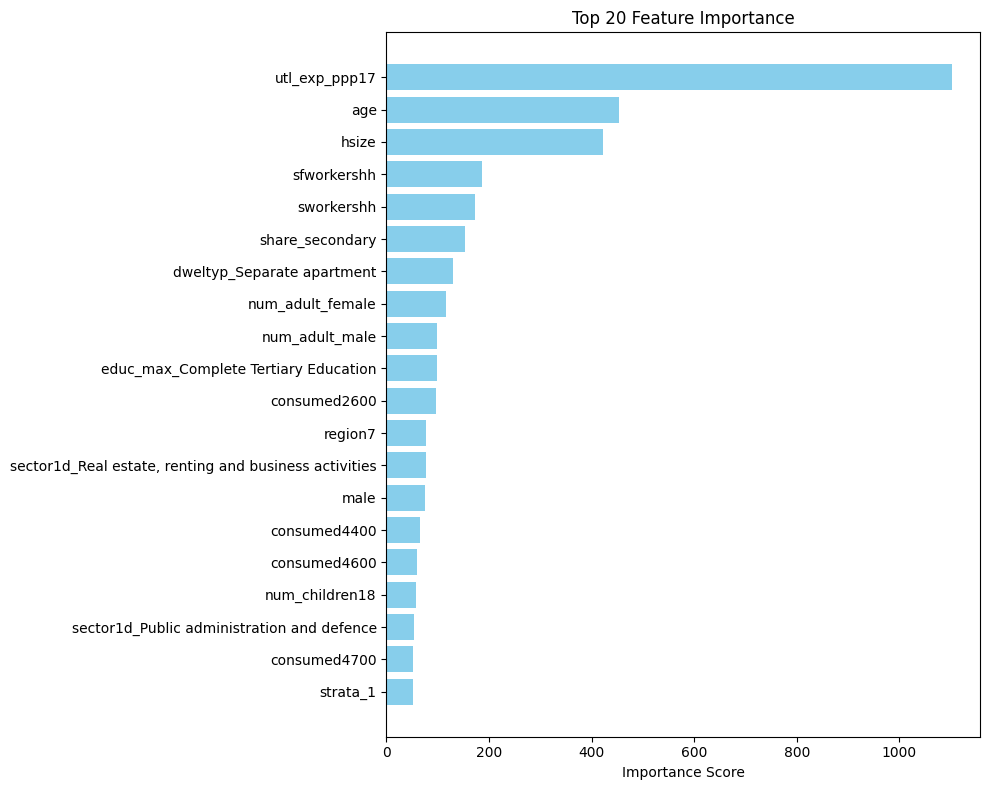

In [67]:
importance = model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

## SVR model

### Use standard Scaler

In [ ]:
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

### Final Training

In [ ]:
svc = SVR(gamma='auto')
svc.fit(X_train, y_train, sample_weight=np.asarray(train_weight))
y_pred = svc.predict(X_test)


rmse = np.sqrt(
    np.average((np.asarray(y_test) - y_pred) ** 2, weights=np.asarray(test_weight))
)

r2 = r2_score(
    y_test,
    y_pred,
    sample_weight=np.asarray(test_weight)
)

mae = mean_absolute_error(y_test, y_pred, sample_weight=np.array(test_weight))

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')
print(f'Mae: {mae:.3f}')

RMSE: 7.380
R²: 0.377
Mae: 4.605


## Linear Regressor

In [67]:
lr = LinearRegression()
lr.fit(X_train, y_train, sample_weight = train_weight)
y_pred = lr.predict(X_test)

rmse = np.sqrt(
    np.average((np.asarray(y_test) - y_pred) ** 2, weights=np.asarray(test_weight))
)

r2 = r2_score(
    y_test,
    y_pred,
    sample_weight=np.asarray(test_weight)
)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 6.422
R²: 0.528


In [103]:
min(history.history['val_mean_squared_error'])

0.41933849453926086

## Deep learning model

In [ ]:
def initialize_model():
    NN_model = Sequential()

    # The Input Layer
    NN_model.add(Dense(256, kernel_initializer='he_normal', input_dim = X_train.shape[1]))
    NN_model.add(BatchNormalization())
    NN_model.add(Activation('relu'))
    NN_model.add(Dropout(0.2))
    
    # The Hidden Layers
    NN_model.add(Dense(256, kernel_initializer='he_normal'))
    NN_model.add(BatchNormalization())
    NN_model.add(Activation('relu'))
    NN_model.add(Dropout(0.2))
    
    NN_model.add(Dense(128, kernel_initializer='he_normal'))
    NN_model.add(BatchNormalization())
    NN_model.add(Activation('relu'))
    NN_model.add(Dropout(0.1))
    
    NN_model.add(Dense(64, kernel_initializer='he_normal'))
    NN_model.add(BatchNormalization())
    NN_model.add(Activation('relu'))

    # The Output Layer
    NN_model.add(Dense(1, kernel_initializer='he_normal',activation='linear'))

    optimizer = Adam(learning_rate=0.0001)
    
    # Compile the network
    NN_model.compile(
        optimizer=optimizer,
        loss='mean_absolute_error',
        metrics=['mean_absolute_error', 'mean_squared_error', 'root_mean_squared_error']
    )
    NN_model.summary()
    return NN_model

In [164]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state = seed)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state = seed)
X_test = test
train_weight = X_train.weight
test_weight = X_test.weight
val_weight = X_val.weight

X_train = X_train.drop(['weight'], axis=1)
X_test = X_test.drop(['weight'], axis=1)
X_val = X_val.drop(['weight'], axis=1)
# X_train = X
# y_train = y
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
# print('y_test shape:', y_test.shape)
print('X_val shape:', X_val.shape)
print('y_val shape:', y_val.shape)

X_train shape: (93571, 133)
y_train shape: (93571,)
X_test shape: (103023, 133)
X_val shape: (10397, 133)
y_val shape: (10397,)


### Scale features 

In [165]:
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_val[scale_columns] = scaler.transform(X_val[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])


### Scale labels 

In [ ]:

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = y_scaler.transform(y_val.values.reshape(-1, 1))
# y_test_scaled   = y_scaler.transform(y_test.values.reshape(-1, 1))

## Scale weights 

In [167]:
train_weight = train_weight / np.mean(train_weight)
val_weight   = val_weight / np.mean(val_weight) 
test_weight   = test_weight / np.mean(test_weight) 

In [168]:
callback = EarlyStopping(monitor='val_mean_absolute_error', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_mean_absolute_error',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)

X_train = X_train.drop(idx_col, axis=1) 
X_val = X_val.drop(idx_col, axis=1)

NN_model = initialize_model()
history = NN_model.fit(
    X_train,
    y_train_scaled,
    sample_weight=train_weight,
    validation_data=(X_val, y_val_scaled, val_weight),
    epochs=100,
    batch_size=32,
    callbacks=[callback],
    verbose=1
)

c:\Users\themmanouilidis\Thanasis_VsCodes\demo_ONLY_TEST\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,617 (561.00 KB)

 Trainable params: 142,209 (555.50 KB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/100
2925/2925 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.5229 - mean_absolute_error: 0.5735 - mean_squared_error: 0.8209 - root_mean_squared_error: 0.9060 - val_loss: 0.3631 - val_mean_absolute_error: 0.4058 - val_mean_squared_error: 0.5666 - val_root_mean_squared_error: 0.7527
Epoch 2/100
2925/2925 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.3943 - mean_absolute_error: 0.4391 - mean_squared_error: 0.5818 - root_mean_squared_error: 0.7627 - val_loss: 0.3261 - val_mean_absolute_error: 0.3649 - val_mean_squared_error: 0.4897 - val_root_mean_squared_error: 0.6998
Epoch 3/100
2925/2925 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.3524 - mean_absolute_error: 0.3969 - mean_squared_error: 0.5166 - root_mean_squared_error: 0.7188 - val_loss: 0.3151 - val_mean_absolute_error: 0.3520 - val_mean_squared_error: 0.4772 - val_root_mean_squared_error: 0.6908
Epoch 4/100
2925/2925 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.3377 - mean_absolute_error: 0.3791 - mean_squared_error: 0.4931 - root_mea

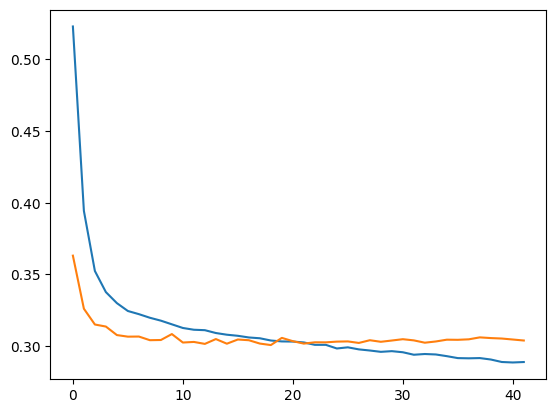

In [169]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.show()

In [175]:
min(history.history['val_mean_squared_error'])

0.41819900274276733

### Same code to create two csv files

In [191]:
# Prediction
y_test_scaled_pred = NN_model.predict(X_test.drop(['hhid', 'survey_id'], axis=1 ))

# Inverse scaling 
y_test_pred = y_scaler.inverse_transform(y_test_scaled_pred).ravel()

# Merge predictions with keys
merged = pd.DataFrame(y_test_pred, columns=['cons_ppp17'])
final = pd.concat([first, merged], axis=1)
final = final.sort_values(by='hhid')
final.to_csv('predicted_household_consumption.csv', index=False)
final


3220/3220 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step


,survey_id,hhid,cons_ppp17
0,400000,400001,9.731033
1,400000,400002,6.781516
2,400000,400003,7.259472
3,400000,400004,9.773503
4,400000,400005,5.106408
...,...,...,...
102475,600000,634209,6.369374
102476,600000,634210,4.151903
102477,600000,634211,6.547558
102478,600000,634212,7.112985


In [192]:
df_test = pd.concat([keys, merged], axis=1)
df_test

,survey_id,hhid,weight,cons_ppp17
0,400000,400001,320,9.731033
1,400000,400002,480,6.781516
2,400000,400003,320,7.259472
3,400000,400004,320,9.773503
4,400000,400005,320,5.106408
...,...,...,...,...
103018,600000,633999,666,3.600491
103019,600000,634024,136,6.229727
103020,600000,634026,408,5.108525
103021,600000,634028,272,6.268119


In [193]:
thresholds = [3.17, 3.94, 4.60, 5.26, 5.88, 6.47, 7.06, 7.70, 8.40, 9.13,
              9.87, 10.70, 11.62, 12.69, 14.03, 15.64, 17.76, 20.99, 27.37]

def poverty_row_for_survey(g, pred_col="cons_ppp17", w_col="weight"):
    w = g[w_col].astype(float)
    denom = w.sum()
    out = {}
    for t in thresholds:
        col = f"pct_hh_below_{t:.2f}"
        out[col] = (w[g[pred_col] < t].sum() / denom) if denom > 0 else 0.0
    return out

rows = []
for sid, g in df_test.groupby("survey_id"):
    row = {"survey_id": sid}
    row.update(poverty_row_for_survey(g))
    rows.append(row)

poverty_df = pd.DataFrame(rows).sort_values("survey_id")
poverty_df.to_csv("predicted_poverty_distribution.csv", index=False)
